In [1]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import demesdraw
import demes

In [2]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [9]:
# Load best-fit models and data

u = 1.3e-8

graph_0 = "results/model_0_Bherer_rep7.yaml"
graph_1 = "results/model_1_Bherer_rep5.yaml"
graph_2 = "results/model_2_Bherer_rep5.yaml"
graph_3 = "results/model_3_Bherer_rep3.yaml"

params_0 = "models/model_0_params.yaml"
params_1 = "models/model_1_params.yaml"
params_2 = "models/model_2_params.yaml"
params_3 = "models/model_3_params.yaml"

data_file = "../../../../analyses/recombination_maps/stats/subset_Bherer.pkl"

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_0, return_dict=True)

model_0 = dpluspy.inference.compute_bin_stats(graph_0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model_1 = dpluspy.inference.compute_bin_stats(graph_1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model_2 = dpluspy.inference.compute_bin_stats(graph_2, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model_3 = dpluspy.inference.compute_bin_stats(graph_3, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

ll0 = dpluspy.inference.composite_ll(model_0, data["means"], data["varcovs"])
ll1 = dpluspy.inference.composite_ll(model_1, data["means"], data["varcovs"])
ll2 = dpluspy.inference.composite_ll(model_2, data["means"], data["varcovs"])
ll3 = dpluspy.inference.composite_ll(model_3, data["means"], data["varcovs"])
print(ll0)
print(ll1)
print(ll2) 
print(ll3)

-1144.304964083613
-631.6760762601408
-495.9758650805535
-546.5520435482164


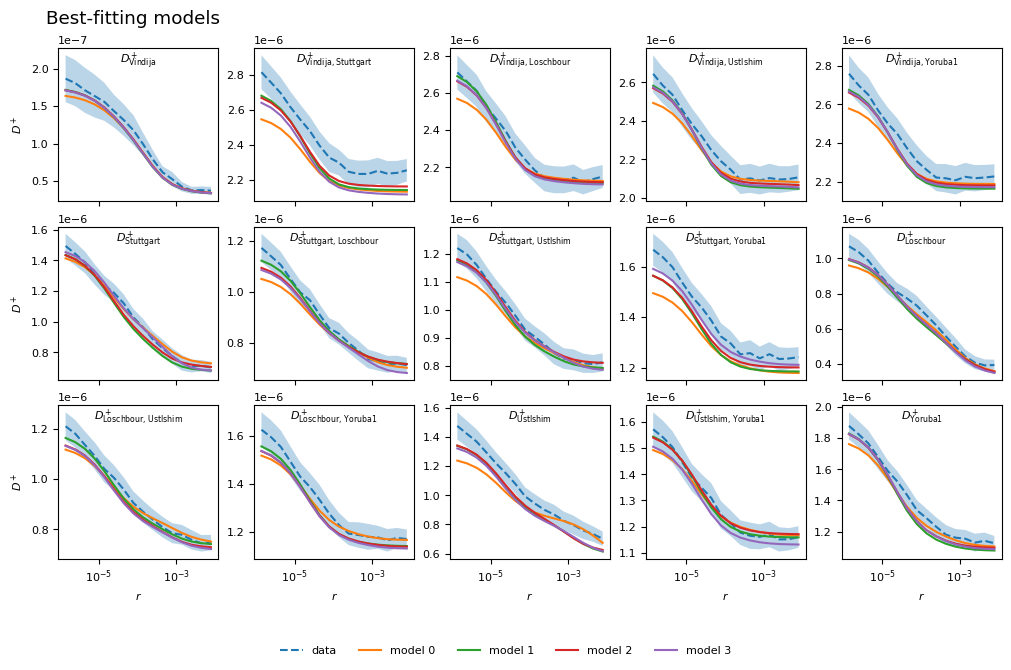

In [13]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model_0, model_1, model_2, model_3],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    labels=["data", "model 0", "model 1", "model 2", "model 3"],
    title="Best-fitting models",
    out="figures/best_fits.pdf"
)

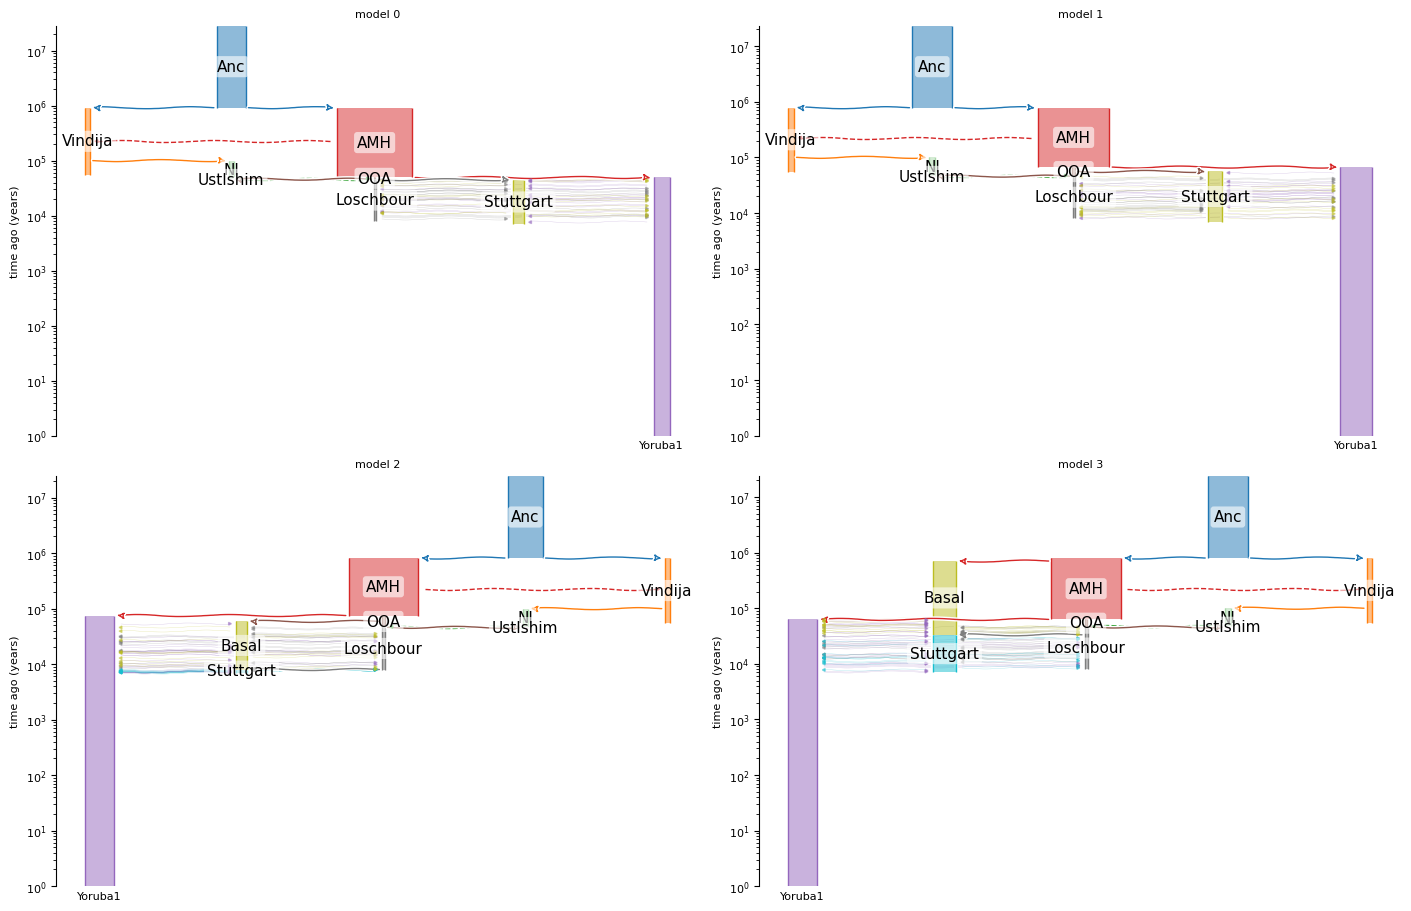

In [8]:
fig, axs = plt.subplots(2, 2, layout="constrained", figsize=(14,9))
axs = axs.flat

demesdraw.tubes(demes.load(graph_0), log_time=True, ax=axs[0])
axs[0].set_title("model 0")
demesdraw.tubes(demes.load(graph_1), log_time=True, ax=axs[1])
axs[1].set_title("model 1")
demesdraw.tubes(demes.load(graph_2), log_time=True, ax=axs[2])
axs[2].set_title("model 2")
demesdraw.tubes(demes.load(graph_3), log_time=True, ax=axs[3])
axs[3].set_title("model 3")
plt.savefig("figures/best_fit_graphs.pdf")

In [11]:
pnames, pvals, uncerts = dpluspy.uncerts.GIM_uncerts(
    graph_3,
    params_3,
    data["means"],
    data["varcovs"],
    pop_ids=data["pop_ids"],
    bins=data["bins"],
    u=1.3e-8,
    bootreps=data["replicates"]
)

[29-07-25 12:47:42] Evaluated Hessian element (0, 0)
[29-07-25 12:47:45] Evaluated Hessian element (0, 1)
[29-07-25 12:47:49] Evaluated Hessian element (0, 2)
[29-07-25 12:47:53] Evaluated Hessian element (0, 3)
[29-07-25 12:47:57] Evaluated Hessian element (0, 4)
[29-07-25 12:48:02] Evaluated Hessian element (0, 5)
[29-07-25 12:48:05] Evaluated Hessian element (0, 6)
[29-07-25 12:48:09] Evaluated Hessian element (0, 7)
[29-07-25 12:48:13] Evaluated Hessian element (0, 8)
[29-07-25 12:48:17] Evaluated Hessian element (0, 9)
[29-07-25 12:48:21] Evaluated Hessian element (0, 10)
[29-07-25 12:48:25] Evaluated Hessian element (0, 11)
[29-07-25 12:48:29] Evaluated Hessian element (0, 12)
[29-07-25 12:48:33] Evaluated Hessian element (0, 13)
[29-07-25 12:48:37] Evaluated Hessian element (0, 14)
[29-07-25 12:48:39] Evaluated Hessian element (1, 1)
[29-07-25 12:48:43] Evaluated Hessian element (1, 2)
[29-07-25 12:48:46] Evaluated Hessian element (1, 3)
[29-07-25 12:48:50] Evaluated Hessian ele

In [14]:
print("Parameter\t2.5% \t97.5%")
for pname, pval, uu in zip(pnames, pvals, uncerts):
    print(f"{pname}\t{pval - 1.96 * uu:.3}\t{pval + 1.96 * uu:.3}")

Parameter	2.5% 	97.5%
T_NH	7.48e+05	8.53e+05
T_Basal	5.61e+05	8.51e+05
T_OOA	5.82e+04	6.77e+04
T_Stu	3.08e+04	3.57e+04
N_Anc	1.49e+04	1.66e+04
N_Vin	2.08e+03	2.41e+03
N_AMH	2.56e+04	2.93e+04
N_Yor	7.37e+03	1.57e+04
N_OOA	6.03e+02	1.06e+03
N_Los	8.98e+02	1.31e+03
N_Stu	3.84e+03	1.43e+04
p_Bas_Stu	0.0679	0.114
m_LosYor	6.77e-05	0.000135
m_StuYor	1.09e-05	6.85e-05
m_LosStu	1.06e-05	0.000107
